In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import numpy as np

In [3]:
electricity_df = pd.read_csv(r"C:\Users\user\Desktop\electricity_bill.csv")
print(electricity_df.columns)
electricity_df.head()

Index(['Units_Consumed', 'Electricity_Bill'], dtype='object')


,Units_Consumed,Electricity_Bill
0,152,1010.93
1,485,3861.19
2,398,3210.64
3,320,2678.67
4,156,1239.04


In [4]:
electricity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Units_Consumed    500 non-null    int64  
 1   Electricity_Bill  500 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


In [5]:
electricity_df.isna().sum()

Units_Consumed      0
Electricity_Bill    0
dtype: int64

In [6]:
#To identify input output variables
x = electricity_df[["Units_Consumed"]]
y= electricity_df["Electricity_Bill"]

In [7]:
#splitting the dataset in training and testing 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [8]:
x_train.shape

(400, 1)

In [9]:
x.shape

(500, 1)

In [10]:
#selecting the machine learning algorithm
from sklearn.linear_model import LinearRegression
electricity_linear_regression_model = LinearRegression()
# Train the model
electricity_linear_regression_model.fit(x_train, y_train)

LinearRegression()

In [11]:
#testing the data (predicting)
y_pred = electricity_linear_regression_model.predict(x_test)
y_pred

array([1962.6179869 , 1074.33162998, 3456.19681711, 2457.85728323,
        854.22527605, 2662.24175473, 1970.47892811, 1074.33162998,
       3802.07823042, 3975.01893708, 1396.63021966,  924.97374696,
        469.03915668, 1939.03516326, 2615.07610746,  736.31115788,
       1616.73657358,  610.53609849, 1215.82857179, 1946.89610447,
       1640.31939722, 1899.7304572 , 1994.06175174, 3181.0638747 ,
       3267.53422803,  744.17209909,  893.52998211, 3401.17022863,
       2300.638459  , 1593.15374995,  594.81421607, 2072.67116386,
        893.52998211,  846.36433484, 3181.0638747 , 1215.82857179,
        822.78151121, 3825.66105406, 2206.30716446, 3471.91869953,
       3385.44834621, 2827.32152018, 2701.54646079, 1695.3459857 ,
       3149.62010986, 3487.64058196, 1247.27233664, 3039.56693289,
       3369.72646378, 3692.02505346, 2056.94928144,  665.56268697,
       2253.47281173,  571.23139243,  791.33774636, 3487.64058196,
       2119.83681113, 1616.73657358, 3039.56693289,  453.31727

In [12]:
y_test

361    2158.84
73      634.39
374    3400.93
155    2229.05
104     769.93
        ...   
347    3704.56
86     1938.87
75     1039.92
438    2352.00
15     2627.50
Name: Electricity_Bill, Length: 100, dtype: float64

In [13]:
# Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'--------model performance---------')
print(f'Mean squared Error is: {mse:.2f} kwh')
print(f' R2 score is : {r2: 2f}')

--------model performance---------
Mean squared Error is: 69097.67 kwh
 R2 score is :  0.942972


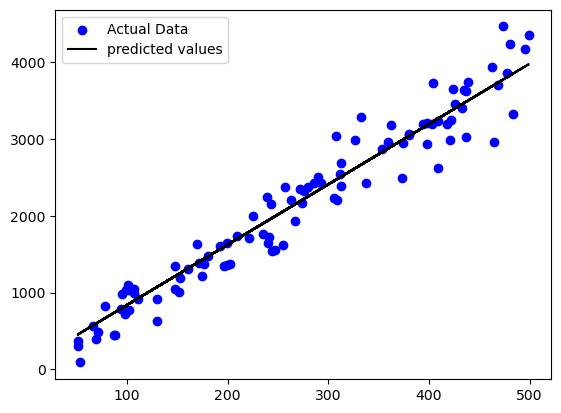

In [14]:
#Visualising the result
import matplotlib.pyplot as plt
plt.scatter(x_test, y_test, color = 'b', label = "Actual Data")
plt.plot(x_test, y_pred, color = "k", label = "predicted values")
plt.legend()
plt.show()

In [15]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import joblib as jb
jb.dump(electricity_linear_regression_model,"electricity_prediction_model.pkl")

['electricity_prediction_model.pkl']

In [ ]:
# Using the model with recommendations
model = jb.load('electricity_prediction_model.pkl')

print(f'{"-"*40}')
print('Welcome to electricity bill predictor application...!')
print(f'{"-"*40}')

try:
    units = float(input("Enter the units consumed to know the total bill: "))
    new_data = np.array([[units]])
    prediction = model.predict(new_data)
    
    total_bill = prediction[0]
    print(f"The predicted Total Bill for {units} units is: {total_bill:.2f} Rupees")
    print(f"{'='*20} USAGE ANALYSIS {'='*20}")
    
    # Defining a threshold value
    threshold = 300 
    
    if units > threshold:
        print("STATUS: HIGH USAGE DETECTED")
        print("Your consumption is above average. Here are some reduction tips:")
        print("1. Switch to LED bulbs to save up to 75% on lighting energy.")
        print("2. Unplug 'phantom' electronics (chargers, TVs) when not in use.")
        print("3. Service your AC/Heater filters to improve efficiency.")
        print("4. Consider using heavy appliances during off-peak hours.")
    else:
        print("STATUS: OPTIMAL USAGE")
        print("Great job! Your consumption is within a healthy range.")
        print("To save even more, ensure your home is well-insulated.")

except Exception as e:
    print(f"Error: Please enter a valid numerical value. ({e})")

print(f"{'='*40}")
print("Thank you...!")

----------------------------------------
Welcome to electricity bill predictor application...!
----------------------------------------
